In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import lingam
from sklearn.preprocessing import StandardScaler
import pygraphviz
from causallearn.search.FCMBased import lingam
# Allow running from anywhere by adding project root (one level up from this file) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.insert(0, project_root)
from features.builder import (
    get_top_concept_ids)

In [5]:
df =pd.read_csv('../scripts/outputs/conditions_named.csv')

In [44]:
df = pd.read_csv("../scripts/outputs/mimiciv_creatinine_nooverlap_cleaned_new_lessfeat.csv")
df.rename(columns={"label": "Increased_Creatinine"}, inplace=True)
# df.drop(columns=["exposure_ibuprofen","exposure_naproxen"], inplace=True)

In [3]:
# df['gender'] = df['gender'].replace({'FEMALE': 0, 'MALE': 1})
# df.drop(columns=['gender'], inplace=True)
# df_encoded = pd.get_dummies(df, columns=['race'], drop_first=False)
# scaler = StandardScaler()
# df['age_at_outcome'] = scaler.fit_transform(df[['age_at_outcome']])

Finished build prior


100%|██████████| 10/10 [02:18<00:00, 13.82s/it]


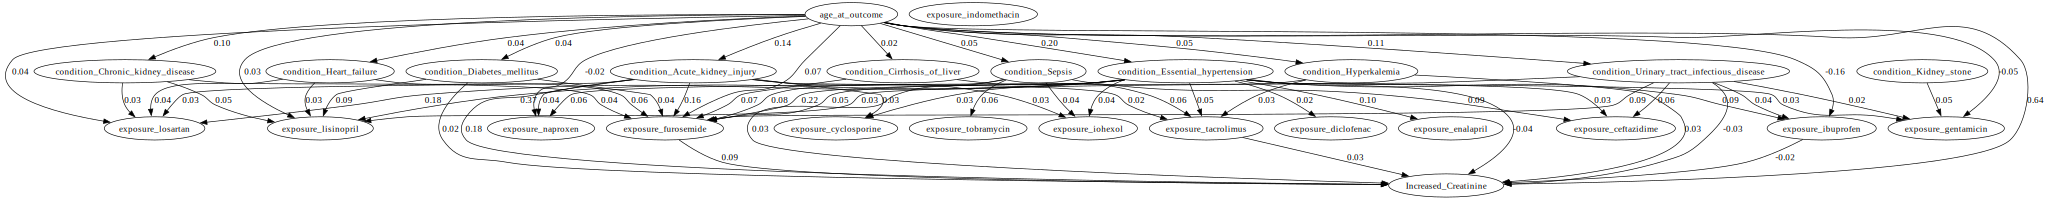

In [47]:
import numpy as np
import pandas as pd
import lingam
from tqdm import tqdm

def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    # Standardize every column to mean 0, std 1 (safe for binary too)
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

def build_prior(df,
                age_col="age_at_outcome",
                y_col="Increased_Creatinine",
                drug_prefix="exposure_",
                cond_prefix="condition_",
                forbid_drug_to_cond=True,
                forbid_y_to_pre=True):
    cols = df.columns.tolist()
    p = len(cols)
    prior = np.zeros((p, p))  # 0 unknown, -1 forbidden, 1 required

    age = cols.index(age_col)
    y = cols.index(y_col)

    is_cond = np.array([c.startswith(cond_prefix) for c in cols])
    is_drug = np.array([c.startswith(drug_prefix) for c in cols])

    # nothing -> age
    prior[:, age] = -1
    prior[age, age] = 0

    # outcome cannot cause pre-outcome vars (use only if truly "pre")
    if forbid_y_to_pre:
        prior[y, is_cond] = -1
        prior[y, is_drug] = -1
        prior[y, age] = -1

    # optionally forbid drugs -> conditions
    if forbid_drug_to_cond:
        prior[is_drug[:, None] & is_cond[None, :]] = -1
    
    print("Finished build prior")

    return prior

def bootstrap_lingam(df_z, prior, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    n, p = df_z.shape
    Bs = np.empty((n_boot, p, p), dtype=float)

    for b in tqdm(range(n_boot)):
        idx = rng.integers(0, n, size=n)
        dfb = df_z.iloc[idx].reset_index(drop=True)
        m = lingam.DirectLiNGAM(prior_knowledge=prior)
        m.fit(dfb)
        Bs[b] = m.adjacency_matrix_

    return Bs

def prune_by_stability(Bs, eps=0.10, p_min=0.80, s_min=0.80, use_ci=False, ci=0.95):
    """
    Bs: (B, p, p) bootstrap adjacency matrices
    eps: magnitude threshold (after standardization)
    p_min: selection frequency threshold
    s_min: sign consistency threshold
    use_ci: if True, keep edges whose CI doesn't cross 0 instead of eps+p_min+s_min rules
    """
    B, p, _ = Bs.shape
    abs_B = np.abs(Bs)

    # selection frequency based on eps
    sel = abs_B >= eps
    p_ij = sel.mean(axis=0)

    # sign consistency among selected samples (more stable than using all samples)
    pos = (Bs > 0) & sel
    neg = (Bs < 0) & sel
    pos_rate = np.divide(pos.sum(axis=0), sel.sum(axis=0), out=np.zeros((p, p)), where=sel.sum(axis=0) != 0)
    neg_rate = np.divide(neg.sum(axis=0), sel.sum(axis=0), out=np.zeros((p, p)), where=sel.sum(axis=0) != 0)
    s_ij = np.maximum(pos_rate, neg_rate)

    # typical magnitude and typical signed effect
    m_ij = np.median(abs_B, axis=0)
    med_signed = np.median(Bs, axis=0)

    keep = (p_ij >= p_min) & (s_ij >= s_min) & (m_ij >= eps)

    if use_ci:
        lo = np.quantile(Bs, (1-ci)/2, axis=0)
        hi = np.quantile(Bs, 1-(1-ci)/2, axis=0)
        keep = (lo > 0) | (hi < 0)   # CI does not cross 0

    B_pruned = np.where(keep, med_signed, 0.0)
    return B_pruned, p_ij, s_ij, m_ij

# ---- Usage ----
# 1) standardize
df_z = standardize_df(df)

# 2) constraints
prior = build_prior(df_z,
                    age_col="age_at_outcome",
                    y_col="Increased_Creatinine",
                    forbid_drug_to_cond=True,
                    forbid_y_to_pre=True)

# 3) bootstrap
Bs = bootstrap_lingam(df_z, prior, n_boot=10, seed=0)

# 4) prune (defaults similar to what you pasted)
B_pruned, freq, sign_cons, mag_med = prune_by_stability(
    Bs, eps=0.02, p_min=0.80, s_min=0.80, use_ci=False
)

# 5) visualize (optional: also apply top-k per child AFTER stability)
from lingam.utils import make_dot
dot = make_dot(B_pruned, labels=df_z.columns.tolist())
dot


In [18]:
import numpy as np
import pandas as pd

def all_effects_dataframe(
    B_pruned: np.ndarray,
    Bs: np.ndarray,
    feature_names: list[str],
    eps: float = 0.03,
    ci: float = 0.95,
    drop_zero_pruned: bool = False
) -> pd.DataFrame:
    """
    Build a dataframe of ALL direct causal effects:
    feature_j -> feature_i  (B[i, j])
    """
    cols = feature_names
    p = len(cols)
    B = Bs.shape[0]

    records = []

    for i in range(p):        # target (child)
        for j in range(p):    # source (parent)
            if i == j:
                continue

            # Orientation: B[i, j] = j -> i
            pruned_eff = B_pruned[i, j]
            w = Bs[:, i, j]

            # stability stats
            sel = np.abs(w) >= eps
            freq = sel.mean()

            sign_cons = 0.0
            if sel.sum() > 0:
                sign_cons = max((w[sel] > 0).mean(), (w[sel] < 0).mean())

            med = np.median(w)
            mean = np.mean(w)
            mag_med = np.median(np.abs(w))

            lo = np.quantile(w, (1 - ci) / 2)
            hi = np.quantile(w, 1 - (1 - ci) / 2)

            if drop_zero_pruned and pruned_eff == 0:
                continue

            records.append({
                "source": cols[j],
                "target": cols[i],
                "pruned_effect": pruned_eff,
                # "bootstrap_median_effect": med,
                # "bootstrap_mean_effect": mean,
                # "bootstrap_median_abs_effect": mag_med,
                # "selection_freq": freq,
                # "sign_consistency": sign_cons,
                # f"ci{int(ci*100)}_lo": lo,
                # f"ci{int(ci*100)}_hi": hi,
                # "ci_excludes_0": (lo > 0) | (hi < 0),
                # "sign": int(np.sign(med))
            })

    df_all = pd.DataFrame.from_records(records)

    # # ranking score (use pruned if available, else bootstrap magnitude)
    # score = df_all["pruned_effect"].abs()
    # score_alt = df_all["bootstrap_median_abs_effect"]
    # df_all["rank_score"] = np.where(score > 0, score, score_alt)

    df_all = df_all.sort_values("pruned_effect", ascending=False).reset_index(drop=True)
    df_all.insert(0, "rank", np.arange(1, len(df_all) + 1))

    return df_all


In [48]:
effects_all_df = all_effects_dataframe(
    B_pruned=B_pruned,
    Bs=Bs,
    feature_names=df.columns.tolist(),
    eps=0,
    ci=0.95,
    drop_zero_pruned=False   # True = only edges shown in graph
)

# effects_all_df.to_csv("all_feature_effects.csv", index=False)
effects_all_df


,rank,source,target,pruned_effect
0,1,age_at_outcome,Increased_Creatinine,0.636470
1,2,condition_Essential_hypertension,exposure_lisinopril,0.373169
2,3,condition_Essential_hypertension,exposure_furosemide,0.217601
3,4,age_at_outcome,condition_Essential_hypertension,0.202249
4,5,condition_Essential_hypertension,exposure_losartan,0.184360
...,...,...,...,...
645,646,exposure_ibuprofen,Increased_Creatinine,-0.024594
646,647,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453
647,648,condition_Essential_hypertension,Increased_Creatinine,-0.036847
648,649,age_at_outcome,exposure_gentamicin,-0.047658


In [20]:
furo_out = (
    effects_all_df
    .query("source == 'exposure_furosemide'")
    .sort_values("pruned_effect", ascending=False)
)
furo_out.head(10)

,rank,source,target,pruned_effect
11,12,exposure_furosemide,Increased_Creatinine,0.090276
357,358,exposure_furosemide,exposure_naproxen,0.000000
594,595,exposure_furosemide,exposure_gentamicin,0.000000
578,579,exposure_furosemide,exposure_tobramycin,0.000000
572,573,exposure_furosemide,exposure_lisinopril,0.000000
538,539,exposure_furosemide,exposure_tacrolimus,0.000000
534,535,exposure_furosemide,exposure_cyclosporine,0.000000
515,516,exposure_furosemide,exposure_losartan,0.000000
479,480,exposure_furosemide,exposure_ceftazidime,0.000000
463,464,exposure_furosemide,exposure_indomethacin,0.000000


In [34]:
to_furo = (
    effects_all_df
    .query("target == 'exposure_furosemide'")
    .sort_values("pruned_effect", ascending=False)
)

to_furo.head(10)


,rank,source,target,pruned_effect
2,3,condition_Essential_hypertension,exposure_furosemide,0.217601
6,7,condition_Acute_kidney_injury,exposure_furosemide,0.160365
15,16,condition_Urinary_tract_infectious_disease,exposure_furosemide,0.086136
16,17,condition_Sepsis,exposure_furosemide,0.079952
17,18,condition_Cirrhosis_of_liver,exposure_furosemide,0.074526
18,19,age_at_outcome,exposure_furosemide,0.065886
22,23,condition_Heart_failure,exposure_furosemide,0.059723
26,27,condition_Hyperkalemia,exposure_furosemide,0.049468
33,34,condition_Chronic_kidney_disease,exposure_furosemide,0.040286
35,36,condition_Diabetes_mellitus,exposure_furosemide,0.039614


In [29]:
to_creat = (
    effects_all_df
    .query("target == 'Increased_Creatinine'")
    .sort_values("pruned_effect", ascending=False)
)
to_creat = to_creat[to_creat['pruned_effect'] != 0]

In [31]:
to_creat

,rank,source,target,pruned_effect
0,1,age_at_outcome,Increased_Creatinine,0.636470
5,6,condition_Acute_kidney_injury,Increased_Creatinine,0.184286
11,12,exposure_furosemide,Increased_Creatinine,0.090276
47,48,exposure_tacrolimus,Increased_Creatinine,0.029528
51,52,condition_Hyperkalemia,Increased_Creatinine,0.026015
52,53,condition_Sepsis,Increased_Creatinine,0.025832
58,59,condition_Diabetes_mellitus,Increased_Creatinine,0.021008
645,646,exposure_ibuprofen,Increased_Creatinine,-0.024594
646,647,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453
647,648,condition_Essential_hypertension,Increased_Creatinine,-0.036847


In [30]:
furo_parents = set(to_furo["source"])
creat_parents = set(to_creat["source"])

shared = sorted(furo_parents & creat_parents)

shared


['age_at_outcome',
 'condition_Acute_kidney_injury',
 'condition_Diabetes_mellitus',
 'condition_Essential_hypertension',
 'condition_Hyperkalemia',
 'condition_Sepsis',
 'condition_Urinary_tract_infectious_disease',
 'exposure_ibuprofen',
 'exposure_tacrolimus']

In [33]:
rows = []

for feat in shared:
    furo_row = to_furo[to_furo["source"] == feat].iloc[0]
    creat_row = to_creat[to_creat["source"] == feat].iloc[0]

    rows.append({
        "feature": feat,
        "to_furosemide": furo_row["pruned_effect"],
        "to_creatinine": creat_row["pruned_effect"],
        "abs_to_furo": abs(furo_row["pruned_effect"]),
        "abs_to_creat": abs(creat_row["pruned_effect"]),
    })

shared_df = (
    pd.DataFrame(rows)
    .sort_values("abs_to_creat", ascending=False)
    .reset_index(drop=True)
)

shared_df


,feature,to_furosemide,to_creatinine,abs_to_furo,abs_to_creat
0,age_at_outcome,0.065886,0.636470,0.065886,0.636470
1,condition_Acute_kidney_injury,0.160365,0.184286,0.160365,0.184286
2,condition_Essential_hypertension,0.217601,-0.036847,0.217601,0.036847
3,condition_Urinary_tract_infectious_disease,0.086136,-0.031453,0.086136,0.031453
4,exposure_tacrolimus,0.000000,0.029528,0.000000,0.029528
5,condition_Hyperkalemia,0.049468,0.026015,0.049468,0.026015
6,condition_Sepsis,0.079952,0.025832,0.079952,0.025832
7,exposure_ibuprofen,0.000000,-0.024594,0.000000,0.024594
8,condition_Diabetes_mellitus,0.039614,0.021008,0.039614,0.021008


In [ ]:
to_furo = to_furo[to_furo.pruned_effect != 0]
furo_parents = set(to_furo["source"])
creat_parents = set(to_creat["source"])

furo_only = sorted(furo_parents - creat_parents)

rows = []

for feat in furo_only:
    row = to_furo[to_furo["source"] == feat].iloc[0]
    rows.append({
        "feature": feat,
        "to_furosemide": row["pruned_effect"],
        "abs_to_furo": abs(row["pruned_effect"]),
    })

furo_only_df = (
    pd.DataFrame(rows)
    .sort_values("abs_to_furo", ascending=False)
    .reset_index(drop=True) 
)

furo_only_df


,feature,to_furosemide,abs_to_furo
0,condition_Cirrhosis_of_liver,0.074526,0.074526
1,condition_Heart_failure,0.059723,0.059723
2,condition_Chronic_kidney_disease,0.040286,0.040286


In [ ]:
import numpy as np
import pandas as pd


def effects_table_to_target_correct(
    B_pruned: np.ndarray,
    Bs: np.ndarray,
    feature_names: list[str],
    target: str = "Increased_Creatinine",
    min_keep_only: bool = True,
    add_ci: bool = True,
    ci: float = 0.95
) -> pd.DataFrame:
    cols = feature_names
    p = len(cols)
    t = cols.index(target)

    # Correct orientation: effect(feature -> target) is B[target, feature]
    pruned_eff = B_pruned[t, :].copy()         # length p
    boot_eff   = Bs[:, t, :]                   # shape (B, p)

    med_eff  = np.median(boot_eff, axis=0)
    mean_eff = np.mean(boot_eff, axis=0)
    mag_med  = np.median(np.abs(boot_eff), axis=0)

    df_out = pd.DataFrame({
        "feature": cols,
        "target": target,
        "pruned_effect": pruned_eff,
        # "bootstrap_median_effect": med_eff,
        # "bootstrap_mean_effect": mean_eff,
        # "bootstrap_median_abs_effect": mag_med,
        # "sign": np.sign(med_eff).astype(int),
    })

    # if add_ci:
    #     lo = np.quantile(boot_eff, (1 - ci) / 2, axis=0)
    #     hi = np.quantile(boot_eff, 1 - (1 - ci) / 2, axis=0)
    #     df_out[f"ci{int(ci*100)}_lo"] = lo
    #     df_out[f"ci{int(ci*100)}_hi"] = hi
    #     df_out["ci_excludes_0"] = (lo > 0) | (hi < 0)

    # drop the target itself
    df_out = df_out[df_out["feature"] != target].copy()

    if min_keep_only:
        df_out = df_out[df_out["pruned_effect"] != 0].copy()

    df_out["rank_score"] = df_out["pruned_effect"].abs()
    df_out = df_out.sort_values("rank_score", ascending=False).reset_index(drop=True)
    df_out.insert(0, "rank", np.arange(1, len(df_out) + 1))

    return df_out


In [17]:
effects_df = effects_table_to_target_correct(
    B_pruned=B_pruned,
    Bs=Bs,
    feature_names=df.columns.tolist(),
    target="Increased_Creatinine",
    min_keep_only=False  # set True if you only want nonzero pruned edges
)

effects_df.to_csv("effects_to_increased_creatinine_anastasia.csv", index=False)
effects_df.head(20)



,rank,feature,target,pruned_effect,rank_score
0,1,age_at_outcome,Increased_Creatinine,0.636470,0.636470
1,2,condition_Acute_kidney_injury,Increased_Creatinine,0.184286,0.184286
2,3,exposure_furosemide,Increased_Creatinine,0.090276,0.090276
3,4,condition_Essential_hypertension,Increased_Creatinine,-0.036847,0.036847
4,5,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453,0.031453
5,6,exposure_tacrolimus,Increased_Creatinine,0.029528,0.029528
6,7,condition_Hyperkalemia,Increased_Creatinine,0.026015,0.026015
7,8,condition_Sepsis,Increased_Creatinine,0.025832,0.025832
8,9,exposure_ibuprofen,Increased_Creatinine,-0.024594,0.024594
9,10,condition_Diabetes_mellitus,Increased_Creatinine,0.021008,0.021008


In [72]:
effects_df.head(20)

,rank,feature,target,pruned_effect,bootstrap_median_effect,bootstrap_mean_effect,bootstrap_median_abs_effect,selection_freq,sign_consistency,sign,ci95_lo,ci95_hi,ci_excludes_0,rank_score
0,1,age_at_outcome,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
1,2,exposure_prednisolone,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
2,3,exposure_flucytosine,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
3,4,exposure_ranolazine,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
4,5,exposure_ascorbic_acid,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
5,6,"exposure_albumin_human,_USP",Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
6,7,exposure_hydrochlorothiazide,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
7,8,exposure_betamethasone,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
8,9,exposure_irbesartan,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
9,10,exposure_olmesartan,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0


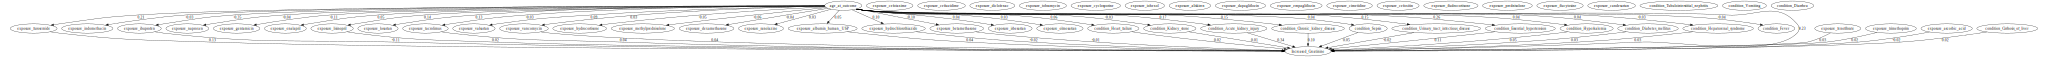

In [5]:
import numpy as np
import pandas as pd
import lingam

def build_minimal_prior(df: pd.DataFrame,
                        age_col="age_at_outcome",
                        y_col="Increased_Creatinine") -> np.ndarray:
    """
    Minimal prior knowledge:
      1) Nothing -> age_col   (age has no parents)
      2) y_col -> nothing     (outcome has no children; cannot cause any variable)
    """
    cols = df.columns.tolist()
    p = len(cols)
    prior = np.zeros((p, p), dtype=int)  # 0 unknown, -1 forbidden, 1 required

    age = cols.index(age_col)
    y = cols.index(y_col)

    # 1) Nothing can cause age: forbid all edges into age (i -> age)
    prior[:, age] = -1
    prior[age, age] = 0  # diagonal irrelevant

    # 2) Outcome cannot cause anything: forbid all edges out of y (y -> j)
    prior[y, :] = -1
    prior[y, y] = 0

    return prior

# --- Run LiNGAM (single fit) ---
# Optional but recommended: standardize so coefficients are comparable
def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

df_z = standardize_df(df)

prior = build_minimal_prior(df_z,
                            age_col="age_at_outcome",
                            y_col="Increased_Creatinine")

def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

df_z = standardize_df(df)
model = lingam.DirectLiNGAM(prior_knowledge=prior)
model.fit(df_z)

B = model.adjacency_matrix_

# visualize
from lingam.utils import make_dot
dot = make_dot(B, labels=df_z.columns.tolist())
dot


In [ ]:
import numpy as np
import lingam

cols = df.columns.tolist()
p = len(cols)
prior = np.zeros((p, p))

age = cols.index("age_at_outcome")
y = cols.index("Increased_Creatinine")

is_cond = np.array([c.startswith("condition_") for c in cols])
is_drug = np.array([c.startswith("exposure_") for c in cols])

# 1) nothing -> age
prior[:, age] = -1
prior[age, age] = 0

# 2) outcome cannot cause pre-outcome vars
prior[y, is_cond] = -1
prior[y, is_drug] = -1
prior[y, age] = -1

# 3) (optional) coarse tiering:
#    forbid drugs -> conditions (if diagnoses are defined before drugs in your data)
prior[is_drug[:, None] & is_cond[None, :]] = -1

#    forbid anything -> outcome? (NO) don't do that; you want parents of outcome allowed.

model = lingam.DirectLiNGAM(prior_knowledge=prior)
model.fit(df)
B = model.adjacency_matrix_


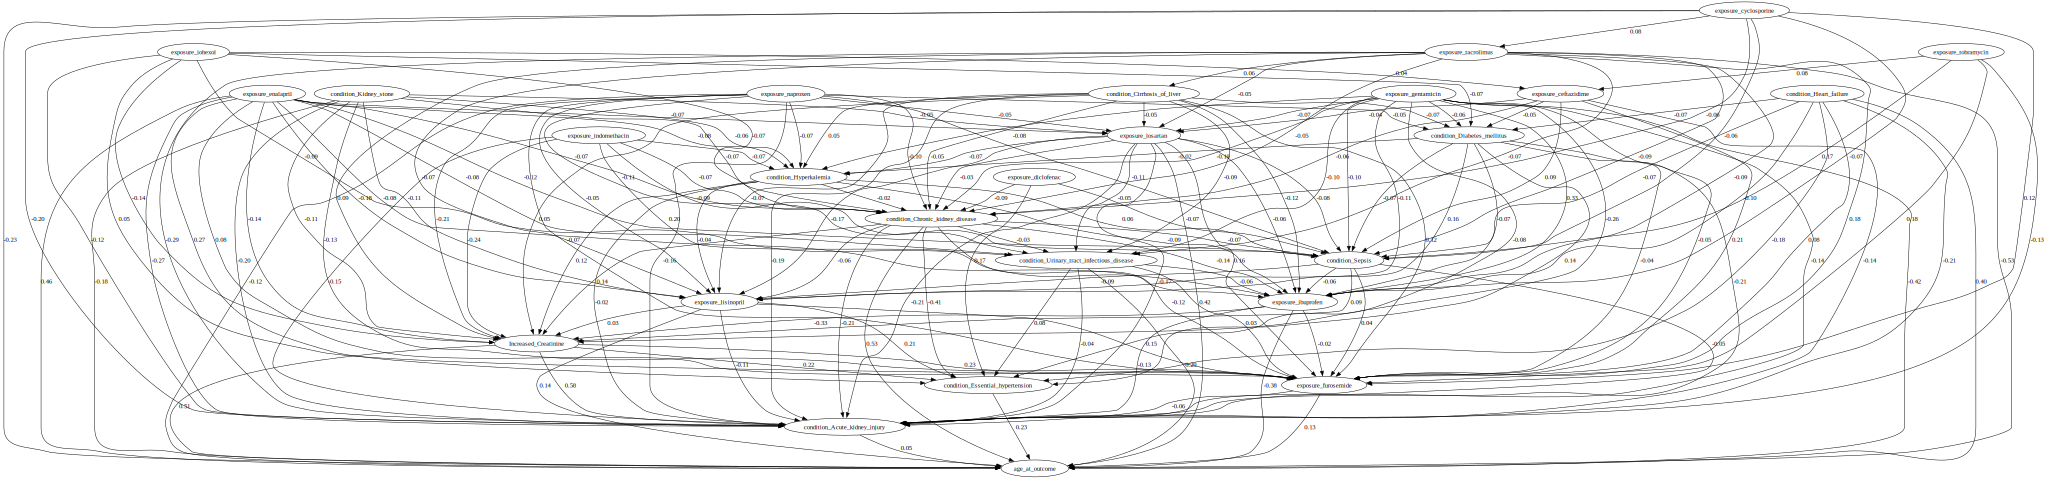

In [8]:
from lingam.utils import make_dot

dot = make_dot(B,labels=df.columns.tolist())
dot